In [1]:
import json
import re
from typing import Tuple, List

import joblib
import pandas as pd
from scipy.stats import uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV



In [2]:

def get_cols(df: pd.DataFrame) -> Tuple[List[str], List[str], List[str], str]:
    """
    Returns predictors to use for the POYM task.

    Args:
        df (pd.DataFrame): Dataframe containing all variables

    Returns:
        List of predictors to use for the POYM task.
    """

    # Comorbidities diagnostic variables
    DX_COLS = [dx for dx in list(df.columns) if re.compile("^(dx_).+").search(dx)]

    # Admission diagnosis variables
    ADM_COLS = [adm for adm in list(df.columns) if re.compile("^(adm_).+").search(adm)]

    # Demographic, previous care utilization and characteristics of the current admission variables
    CAT_COLS = ['gender', 'living_status', 'admission_group', 'service_group']
    CONT_COLS = ["age_original", "ed_visit_count", "ho_ambulance_count", "total_duration"]
    OTHER_BIN_COLS = ["flu_season", "is_ambulance", "is_icu_start_ho", "is_urg_readm", "has_dx"]

    # Target variable
    OYM = "oym"

    # Binary columns
    BIN_COLS = DX_COLS + ADM_COLS + OTHER_BIN_COLS

    return CONT_COLS, BIN_COLS, CAT_COLS, OYM



In [3]:
# Install the data
# Windows =>
# import urllib.request
# url = "https://zenodo.org/records/12954673/files/dataset.csv"
# output_path = "dataset.csv"
# urllib.request.urlretrieve(url, output_path)

# Linux =>
# subprocess.run(" wget https://zenodo.org/records/12954673/files/dataset.csv", shell=True, check=True)




In [4]:
# Read the data
data = pd.read_csv('dataset.csv')
cont_cols, bin_cols, cat_cols, target = get_cols(data)

# Select one single visit per patient to avoid data leakage
data = data.groupby("patient_id").apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)



### Analyse correlation with target variable

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# from imblearn.over_sampling import SMOTE
# from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd

%load_ext autoreload
%autoreload 2

In [6]:
def feature_encoding(X):
    """
    One-hot encode the 'features'.
    Input: X: features (pd.DataFrame)
    Output: X: features_encoded (pd.DataFrame)
    """
    non_numerical_columns_names = X.select_dtypes(exclude=['number']).columns
    le = LabelEncoder()
    for column in non_numerical_columns_names:
        # Only encore the columns that are not numerical 
        X[column] = le.fit_transform(X[column])

    return X

def normalize_features(X_train, X_validation, X_test, Is_Standard_scaler = True):
    """
    Take the input data and normalize the features.
    Input: X_train: features for train,  X_test: features for test (pd.DataFrame)
    Output: X_train_scaled, X_test_scaled (pd.DataFrame) the same shape of X_train and X_test
    """
    if Is_Standard_scaler: scaler = StandardScaler()
    else: scaler = MinMaxScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_validation_scaled = scaler.transform(X_validation)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_validation_scaled, X_test_scaled

In [7]:
# One hot encoding for categorical variables
onehot_data = pd.get_dummies(data, columns=cat_cols,  dtype=int)
onehot_cat_cols = [c for c in onehot_data.columns if c not in data.columns]

feature_cols = cont_cols + bin_cols + onehot_cat_cols

In [8]:
print('len(x_train):', len(onehot_data))
onehot_data.isnull().sum()


len(x_train): 123646


patient_id                        0
visit_id                          0
age_original                      0
ed_visit_count                    0
ho_ambulance_count                0
                                 ..
service_group_rhumatology         0
service_group_thoracic_surgery    0
service_group_trauma              0
service_group_urology             0
service_group_vascular_surgery    0
Length: 281, dtype: int64

In [9]:
onehot_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123646 entries, 0 to 123645
Columns: 281 entries, patient_id to service_group_vascular_surgery
dtypes: bool(2), int32(37), int64(242)
memory usage: 246.0 MB


In [10]:
# check amount of columns
print('Number of feature columns:', len(feature_cols))

Number of feature columns: 277


In [11]:
# what is the target variable?
print('Target variable:', target)

Target variable: oym


<Axes: title={'center': 'Correlation with oym'}>

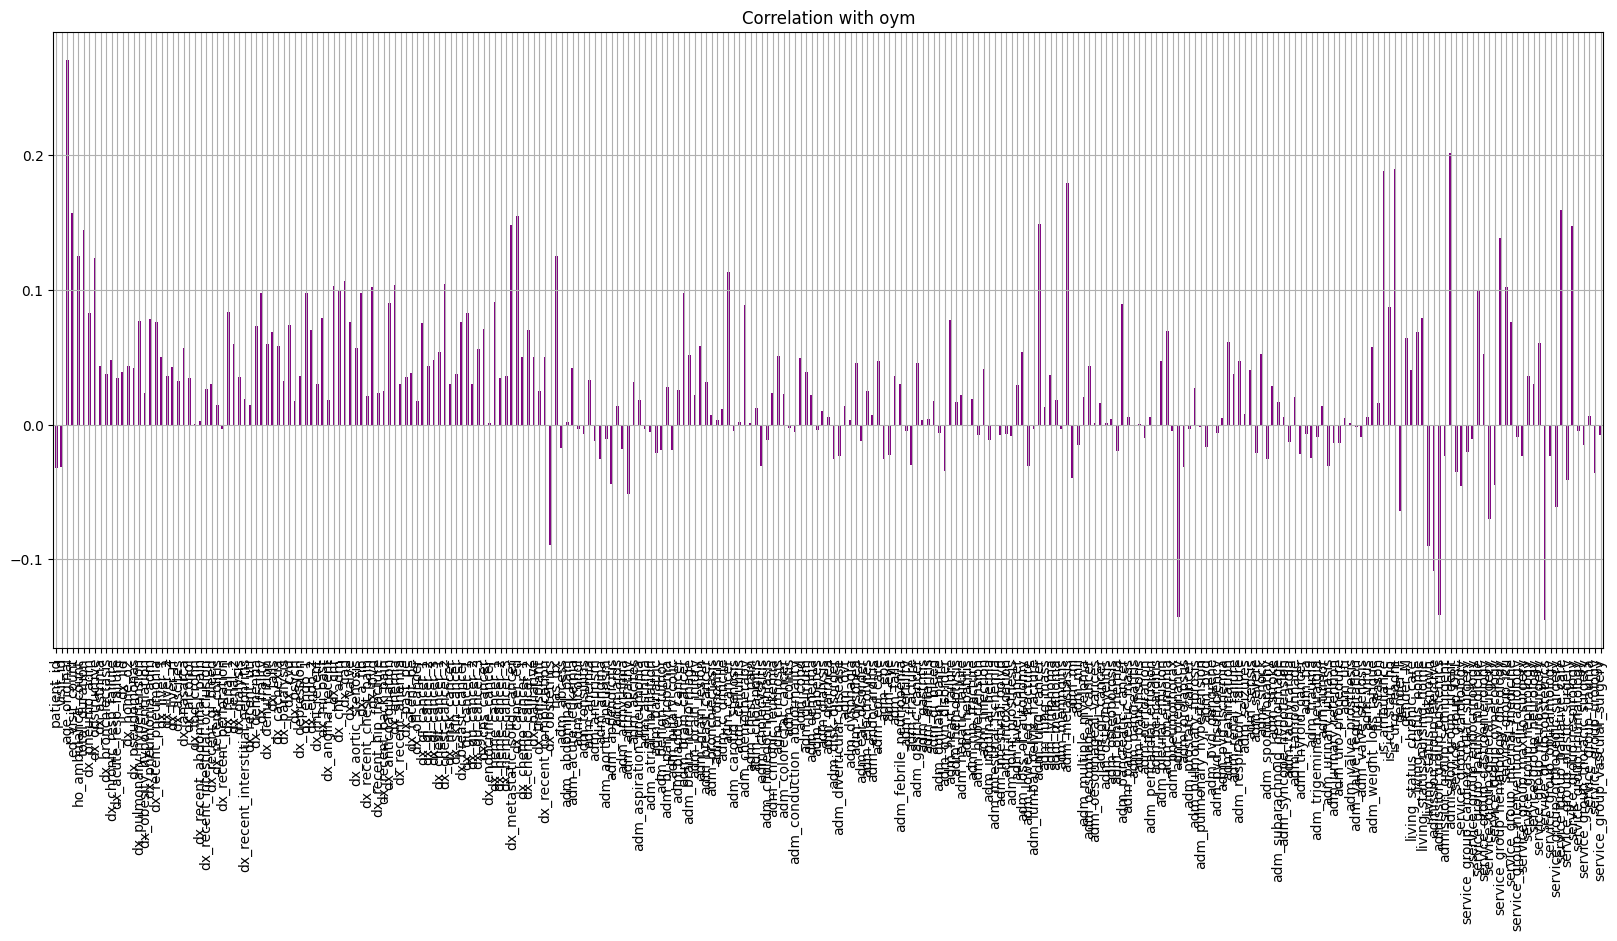

In [12]:



# Filter numeric columns only from X
X_numeric = onehot_data.select_dtypes(include=[np.number])

# Compute correlation with y
X_numeric.corrwith(onehot_data[target]).plot(kind='bar', grid=True, figsize=(20, 8),
                                              title="Correlation with oym", color="Purple")


In [13]:
# Remove all features with correlation less than a threshold
corr_threshold = 0.07
corr = onehot_data.corr()
low_corr_features = corr.index[abs(corr[target]) < corr_threshold].tolist()
print('Low correlation features to remove:', low_corr_features)
onehot_data = onehot_data.drop(columns=low_corr_features)
print('Number of features after removing low correlation features:', onehot_data.shape[1])


Low correlation features to remove: ['patient_id', 'visit_id', 'dx_asthma', 'dx_bronchiectasis', 'dx_chronic_resp_failure', 'dx_acute_resp_failure', 'dx_ild', 'dx_home_o2', 'dx_pseudomonas', 'dx_obesity_hypoventilation', 'dx_liver_1', 'dx_liver_2', 'dx_liver_rf', 'dx_ascites', 'dx_anasarca', 'dx_alcohol', 'dx_ibd_crohn', 'dx_recent_abdominal_pain', 'dx_recent_intestinal_occlusion', 'dx_recent_gi_bleed', 'dx_recent_colitis', 'dx_recent_perforation', 'dx_renal_2', 'dx_dialysis', 'dx_recent_interstitial_nephritis', 'dx_recent_uti', 'dx_denutrition', 'dx_falls', 'dx_cachexia', 'dx_paralysis', 'dx_psych', 'dx_depression', 'dx_mi_recent', 'dx_angina_recent', 'dx_aortic_stenosis', 'dx_recent_chest_pain', 'dx_recent_hip_fracture', 'dx_recent_back_pain', 'dx_recent_anemia', 'dx_past_pe', 'dx_recent_pe', 'dx_orl_cancer', 'dx_gi_cancer_2', 'dx_gi_cancer_3', 'dx_chest_cancer_1', 'dx_msk_cancer', 'dx_skin_cancer', 'dx_gu_cancer_2', 'dx_gu_cancer_3', 'dx_endocrine_cancer', 'dx_heme_cancer_2', 'dx_he

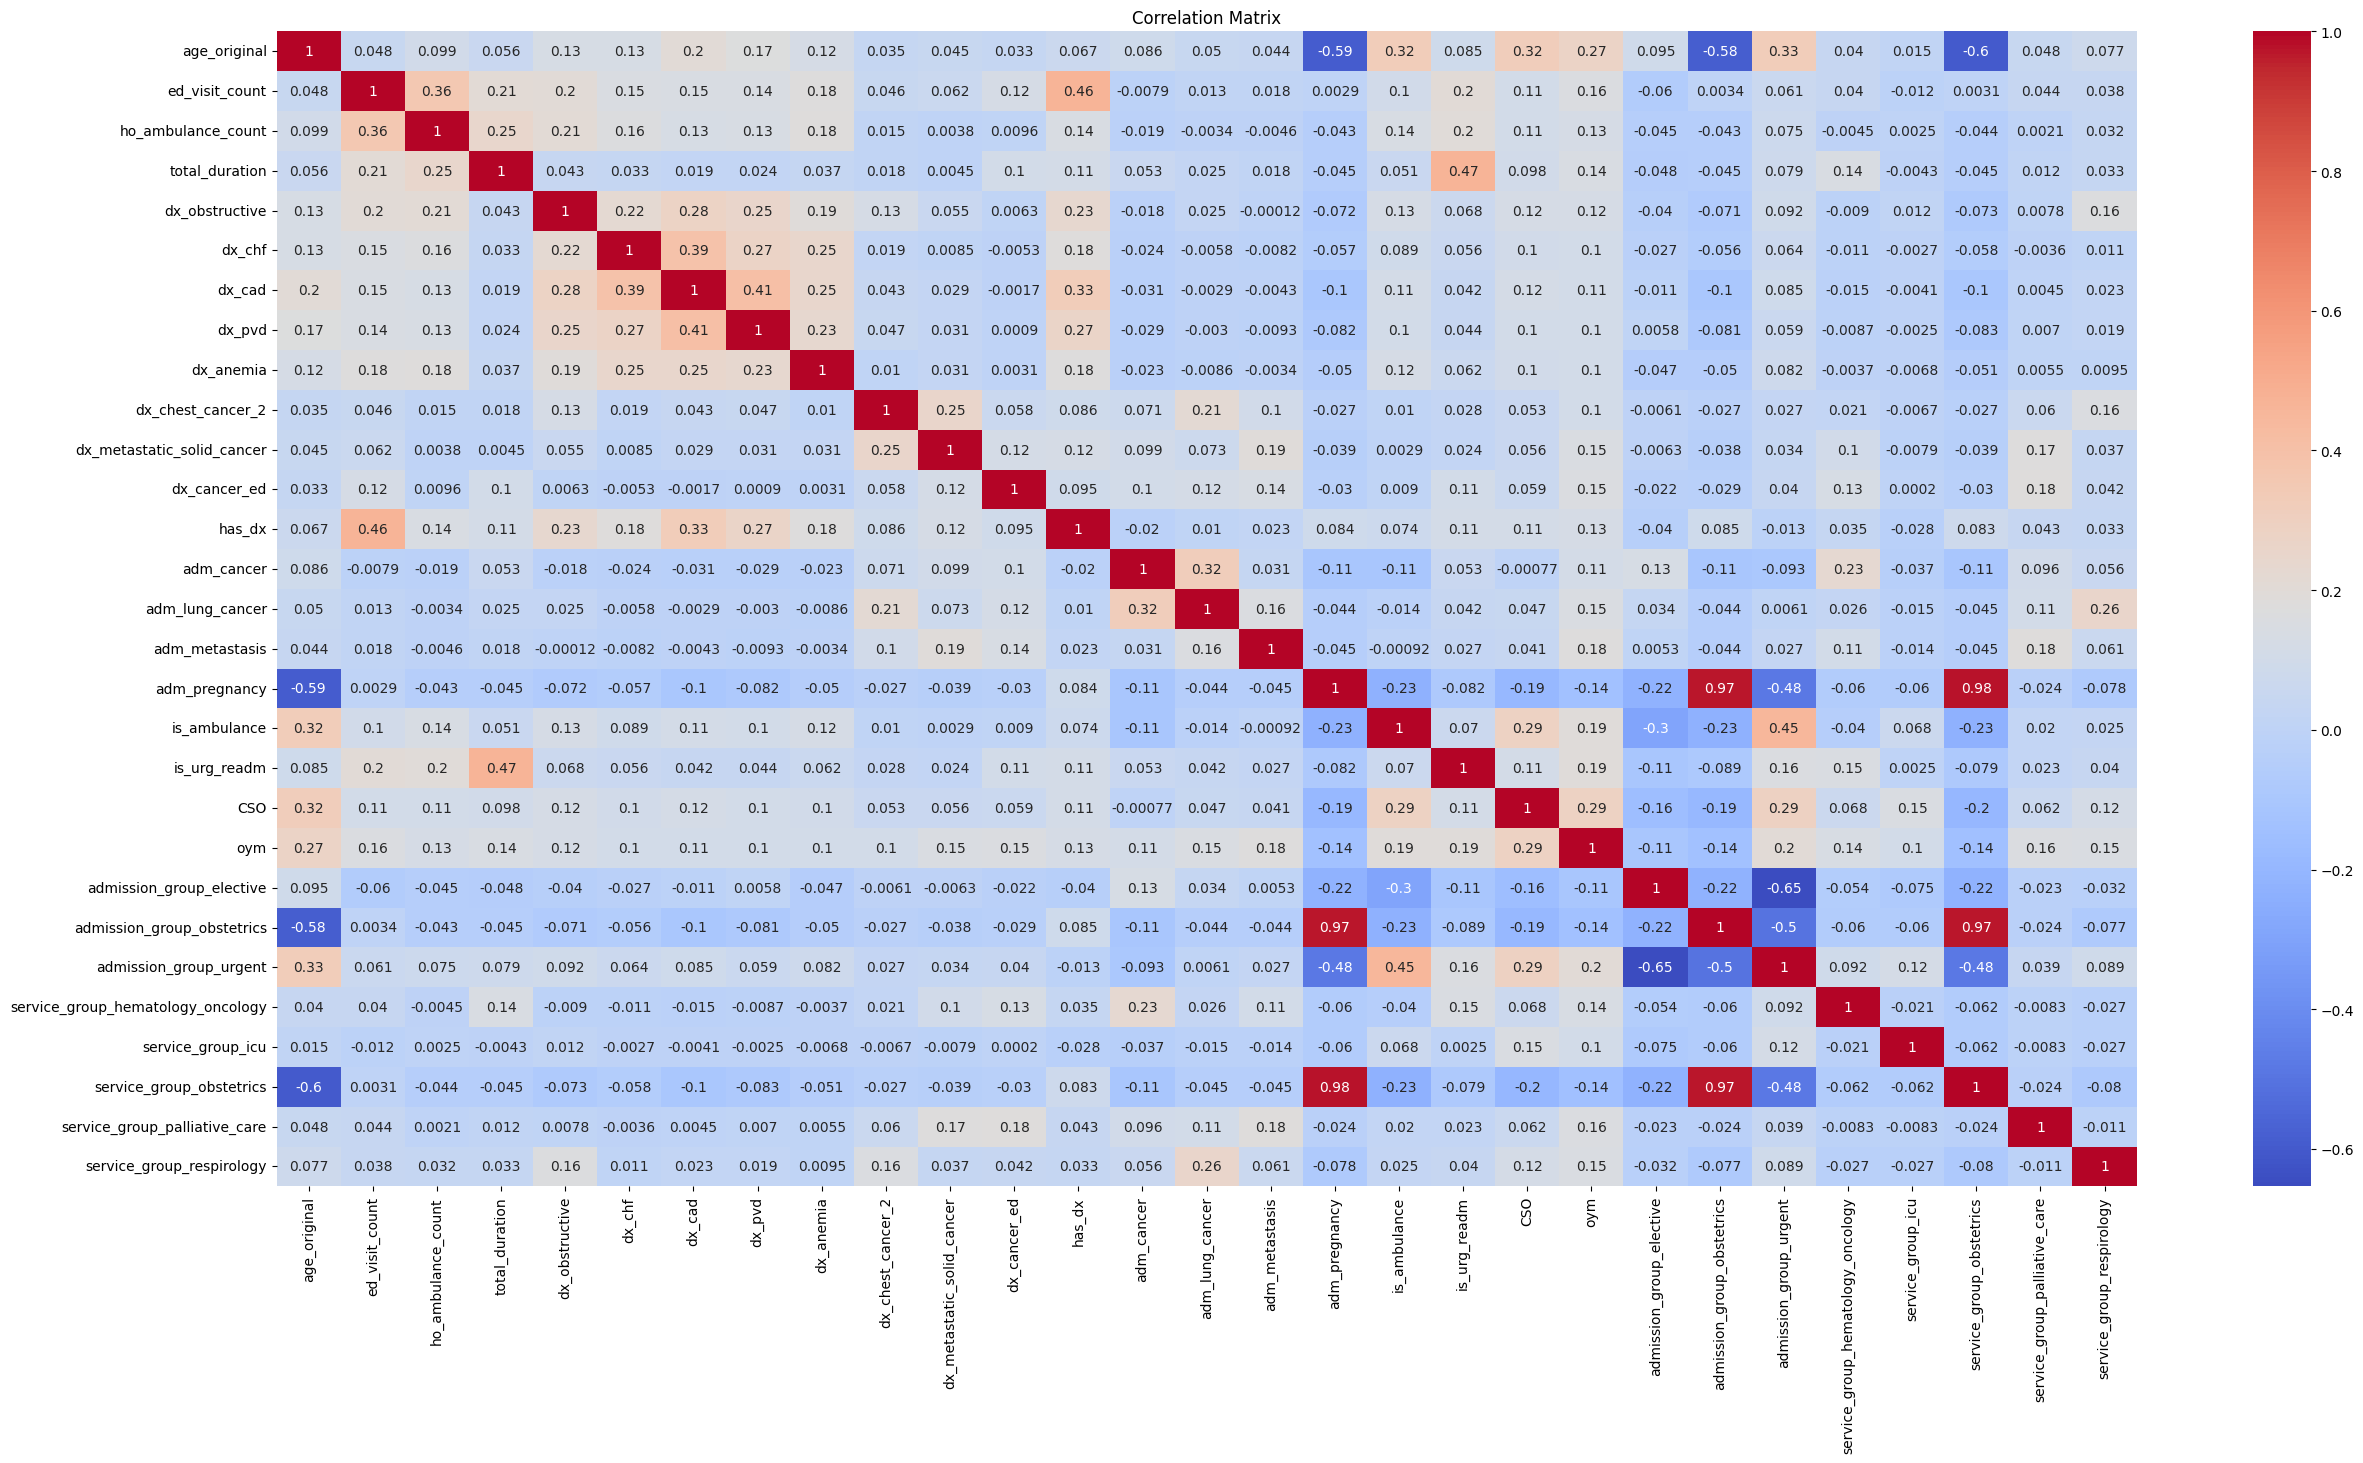

In [14]:

corr_threshold_high = 0.1
high_corr = corr.index[abs(corr[target]) >= corr_threshold_high].tolist()

plt.figure(figsize=(30, 15))
sns.heatmap(corr.loc[high_corr, high_corr], annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



In [15]:
# Remove all features with above 60% correlation with another feature
upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col].abs() > 0.6)]
print("Highly correlated features to remove (raw):", to_drop)

# Keep only the columns that actually exist in the dataframe
to_drop_existing = [col for col in to_drop if col in onehot_data.columns]

print("Actually dropping:", to_drop_existing)

onehot_data = onehot_data.drop(columns=to_drop_existing)

print("Number of features after removing highly correlated features:", onehot_data.shape[1])


Highly correlated features to remove (raw): ['visit_id', 'dx_falls', 'adm_aortic_aneurism', 'adm_uro_procedure', 'gender_M', 'living_status_home', 'living_status_unknown', 'admission_group_obstetrics', 'admission_group_urgent', 'service_group_cardiology', 'service_group_icu', 'service_group_obstetrics', 'service_group_opthalmology']
Actually dropping: ['living_status_unknown', 'admission_group_obstetrics', 'admission_group_urgent', 'service_group_icu', 'service_group_obstetrics']
Number of features after removing highly correlated features: 55


In [16]:
onehot_data = onehot_data.apply(pd.to_numeric, errors="coerce").astype("float32")

# Save columns used
final_feature_cols = [col for col in onehot_data.columns if col != target]
print('Final number of feature columns:', len(final_feature_cols))

Final number of feature columns: 54


In [17]:
# Split to learning and holdout set
x_train, x_test, y_train, y_test = train_test_split(
    onehot_data[final_feature_cols], 
    data[target], 
    test_size=0.5, 
    random_state=42
)

# Scale BEFORE oversampling (correct)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Split off validation set (still BEFORE oversampling)
x_train, x_validation, y_train, y_validation = train_test_split(
    x_train, y_train, 
    test_size=0.1, 
    random_state=42
)

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy=0.5, random_state=42)

x_train_resampled, y_train_resampled = ros.fit_resample(x_train, y_train)


### Neural Network with PyTorch

In [18]:
def soft_auc_loss(y_true, y_pred, gamma=1.0):
    """
    Differentiable AUC surrogate (Soft AUC).

    y_true: (batch,) tensor of 0/1
    y_pred: (batch,) tensor of model logits
    gamma: margin scaling factor
    """

    y_true = y_true.float().view(-1, 1)
    y_pred = y_pred.view(-1, 1)

    # Pairwise difference: f(x_pos) - f(x_neg)
    diff = y_pred - y_pred.t()

    # Label differences: 1 if (i positive, j negative), -1 otherwise
    label_diff = y_true - y_true.t()

    # Only keep positive/negative pairs, ignore same-label pairs
    mask = label_diff != 0
    diff = diff[mask]
    label_diff = label_diff[mask]

    # Soft AUC loss
    loss = torch.sigmoid(-gamma * label_diff * diff).mean()
    return loss


In [19]:
def loss_overtime(train_loss_array, validation_loss_array, model_name):
    plt.figure(figsize=(20, 10))
    if len(train_loss_array) != 0:
        plt.plot(train_loss_array, label='Train Loss')
    if len(validation_loss_array) != 0:
        plt.plot(validation_loss_array, label='Validation Loss')    
    plt.xlabel('Epochs')
    plt.xticks(range(0, len(train_loss_array), 10))
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Loss over time for {model_name}')
    plt.show()

In [20]:
class CustomNN(nn.Module):
    def __init__(self, input_size):
        super(CustomNN, self).__init__()
        self.layers = nn.ModuleList([
            nn.Linear(input_size, 512),
            nn.Linear(512, 512),
            nn.Linear(512, 256),
            nn.Linear(256, 256),
            nn.Linear(256, 128),
            nn.Linear(128, 128),
            nn.Linear(128, 64),
            nn.Linear(64, 64),
            nn.Linear(64, 32),
            nn.Linear(32, 16)
        ])
        self.output = nn.Linear(16, 1)  # Binary classification output layer
        self.dropout = nn.Dropout(0.1)

        # Xavier uniform initialization
        for layer in self.layers:
            if isinstance(layer, nn.Linear):  # Ensure it's a linear layer
                nn.init.xavier_uniform_(layer.weight)

        nn.init.xavier_uniform_(self.output.weight)

    def forward(self, x):
        for layer in self.layers:
            x = F.leaky_relu(layer(x))  # Apply ReLU after each linear layer
            x = self.dropout(x)  # Apply dropout after activation
        x = self.output(x)  # Final output layer (no activation here; handled by BCEWithLogitsLoss)
        return x

In [21]:
import torch
import torch.nn as nn

class CustomNN_v2(nn.Module):
    def __init__(self, input_dim):
        super(CustomNN_v2, self).__init__()

        hidden1 = 256
        hidden2 = 128
        hidden3 = 64

        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(hidden2, hidden3),
            nn.BatchNorm1d(hidden3),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(hidden3, 1)
        )

    def forward(self, x):
        return self.layers(x)


In [22]:
class BCEFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction="none")

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probas = torch.sigmoid(logits)
        pt = probas * targets + (1 - probas) * (1 - targets)
        focal_term = (1 - pt) ** self.gamma
        loss = self.alpha * focal_term * bce_loss
        return loss.mean()


In [23]:
print("Is CUDA available?", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loss_array = []
validation_loss_array = []
F1_score_array = []
best_validation_auc = 0.0
model_name = "custom_nn_v3"

seed = 42
torch.manual_seed(seed)

from torch.utils.data import TensorDataset, DataLoader

# CPU tensors
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_validation_tensor = torch.tensor(x_validation, dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_validation_tensor, y_validation_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

input_size = X_train_tensor.shape[1]
model = CustomNN_v2(input_size).to(device)

optimizer = optim.NAdam(model.parameters(), lr=0.0001)

# ---------- NEW: Weighted BCE ----------
# pos_weight = (neg_count / pos_count)
pos_count = y_train_tensor.sum()
neg_count = len(y_train_tensor) - pos_count
pos_weight = (neg_count / pos_count).to(device)
# criterion = BCEFocalLoss(alpha=0.75, gamma=2)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
loss_fn = criterion
# ----------------------------------------

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch).squeeze(1)
        
        loss  = 0.7 * criterion(logits, y_batch) + 0.3 * soft_auc_loss(y_batch, logits)


        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss_array.append(epoch_loss)

    print(f"Epoch {epoch+1}, Weighted BCE Loss = {epoch_loss:.4f}")

    # ----- VALIDATION -----
    model.eval()
    with torch.no_grad():
        val_logits = model(X_validation_tensor.to(device)).squeeze(1)
        val_pred = torch.sigmoid(val_logits).cpu().numpy()

    validation_auc = roc_auc_score(y_validation, val_pred)
    validation_loss_array.append(validation_auc)

    print(f"Validation AUC: {validation_auc:.4f}")

    if validation_auc > best_validation_auc:
        best_validation_auc = validation_auc
        torch.save(model.state_dict(), f"nn_{model_name}_best.pth")
        print(f"Saved new best model with AUC = {validation_auc:.4f}")


Is CUDA available? True
Epoch 1, Weighted BCE Loss = 175.1714
Validation AUC: 0.8737
Saved new best model with AUC = 0.8737
Epoch 2, Weighted BCE Loss = 149.7540
Validation AUC: 0.8781
Saved new best model with AUC = 0.8781
Epoch 3, Weighted BCE Loss = 140.6686
Validation AUC: 0.8798
Saved new best model with AUC = 0.8798
Epoch 4, Weighted BCE Loss = 135.3562
Validation AUC: 0.8809
Saved new best model with AUC = 0.8809
Epoch 5, Weighted BCE Loss = 132.8892
Validation AUC: 0.8819
Saved new best model with AUC = 0.8819
Epoch 6, Weighted BCE Loss = 130.9325
Validation AUC: 0.8829
Saved new best model with AUC = 0.8829
Epoch 7, Weighted BCE Loss = 129.3158
Validation AUC: 0.8829
Saved new best model with AUC = 0.8829
Epoch 8, Weighted BCE Loss = 129.1161
Validation AUC: 0.8836
Saved new best model with AUC = 0.8836
Epoch 9, Weighted BCE Loss = 128.0057
Validation AUC: 0.8834
Epoch 10, Weighted BCE Loss = 128.0484
Validation AUC: 0.8838
Saved new best model with AUC = 0.8838
Epoch 11, Weig

In [24]:
print(len(train_loss_array), len(validation_loss_array))


20 20


              precision    recall  f1-score   support

       False       0.98      0.77      0.86      5516
        True       0.30      0.85      0.45       667

    accuracy                           0.77      6183
   macro avg       0.64      0.81      0.65      6183
weighted avg       0.90      0.77      0.81      6183

AUC: 0.8861776508410044


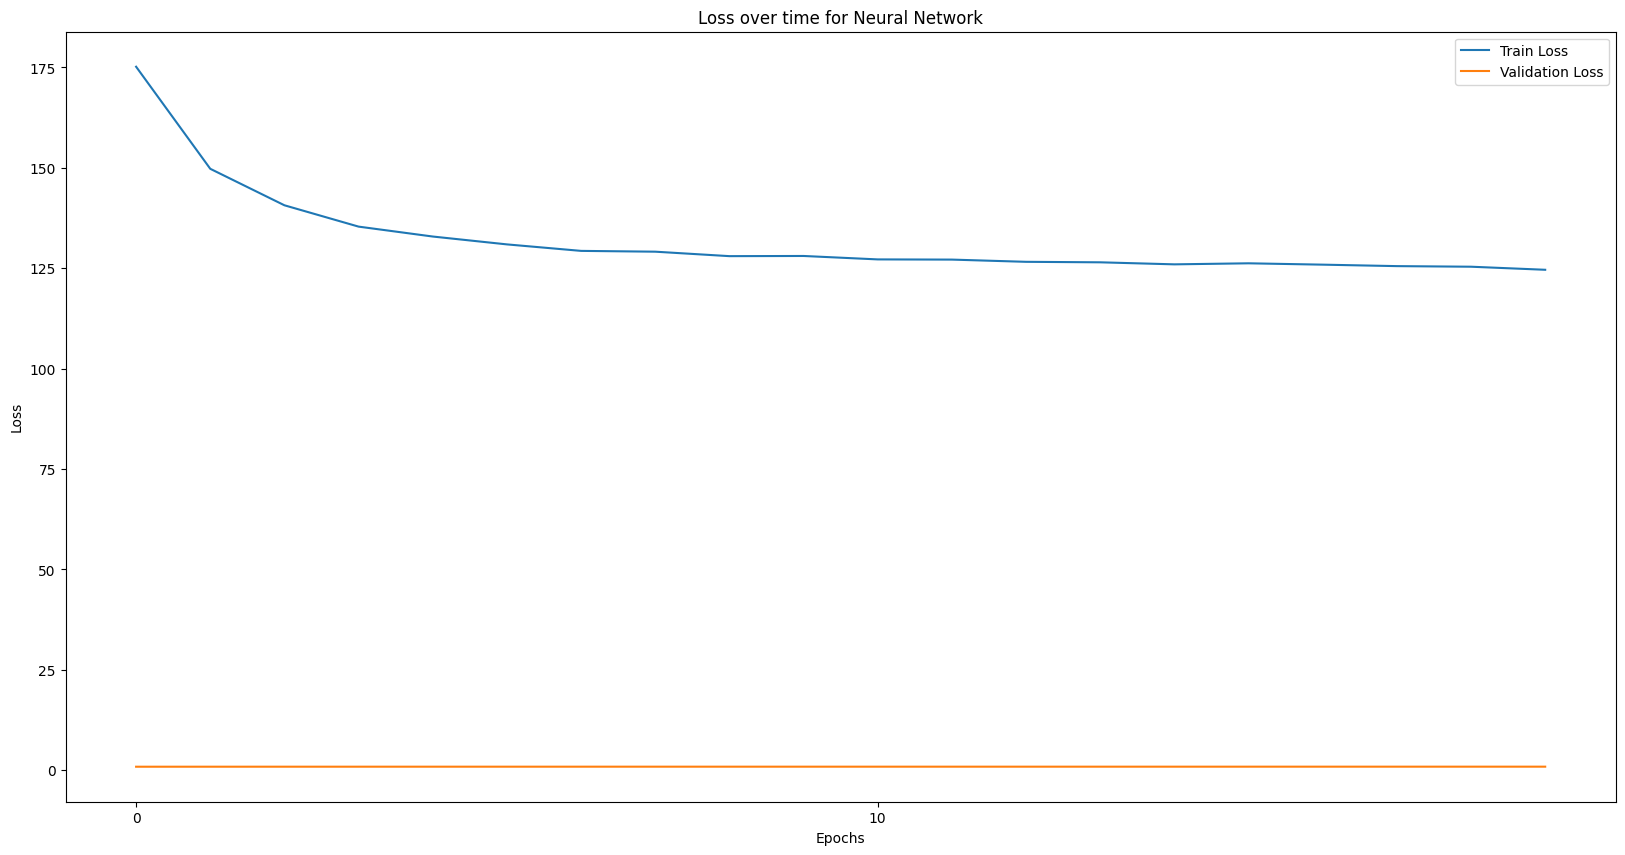

In [25]:
from sklearn.metrics import classification_report, roc_auc_score

# 1. Probabilities from model
model.load_state_dict(torch.load(f"nn_{model_name}_best.pth"))
val_logit = model(X_validation_tensor.to(device)).squeeze(1)

# 2. Convert logits → probabilities safely
val_pred_proba = torch.sigmoid(val_logit).detach().cpu().numpy()

# 3. Convert to binary predictions
val_pred = (val_pred_proba >= 0.5).astype(int)

# 4. Classification report
print(classification_report(y_validation, val_pred))

# 5. AUC
print("AUC:", roc_auc_score(y_validation, val_pred_proba))


loss_overtime(train_loss_array, validation_loss_array, 'Neural Network')


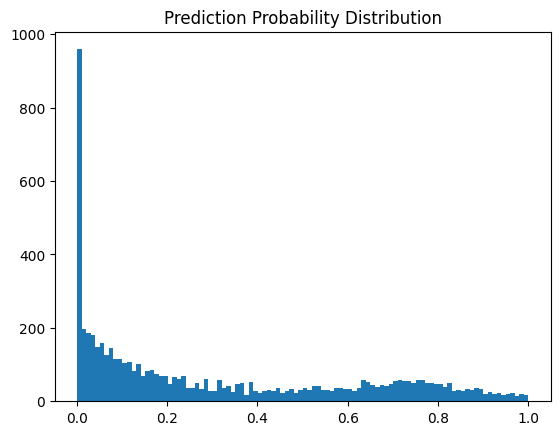

In [26]:
import matplotlib.pyplot as plt
plt.hist(val_pred_proba, bins=100)
plt.title("Prediction Probability Distribution")
plt.show()


In [27]:
from sklearn.metrics import f1_score

best_t = 0
best_f1 = 0

for t in [i/100 for i in range(1,100)]:
    f1 = f1_score(y_validation, (val_pred_proba >= t).astype(int))
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)


Best threshold: 0.72
Best F1: 0.5158150851581509


In [28]:
import numpy as np
from sklearn.metrics import f1_score

# 1. Get model validation probabilities
with torch.no_grad():
    val_pred_proba = torch.sigmoid(
        model(X_validation_tensor.to(device))
    ).cpu().numpy()

# 2. Sweep thresholds
thresholds = np.linspace(0, 1, 200)
best_f1 = -1
best_threshold = 0.5

for t in thresholds:
    preds = (val_pred_proba >= t).astype(int)
    f1 = f1_score(y_validation, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)
y_pred_final = (val_pred_proba >= best_threshold).astype(int)
print(classification_report(y_validation, y_pred_final))


Best threshold: 0.7135678391959799
Best F1: 0.5205479452054794
              precision    recall  f1-score   support

       False       0.96      0.90      0.92      5516
        True       0.43      0.66      0.52       667

    accuracy                           0.87      6183
   macro avg       0.69      0.78      0.72      6183
weighted avg       0.90      0.87      0.88      6183



In [29]:
# Load best model
model.load_state_dict(torch.load(f"nn_{model_name}_best.pth"))
model.eval()

# Build test tensor
X_test_tensor = torch.tensor(
    x_test,
    dtype=torch.float32
).to(device)

with torch.no_grad():
    logits = model(X_test_tensor).squeeze(1)
    y_pred_proba = torch.sigmoid(logits).cpu().numpy()

# Test AUC using probabilities
test_auc = roc_auc_score(y_test, y_pred_proba)
print("Test AUC:", test_auc)

# Apply optimal threshold
y_pred_test = (y_pred_proba >= best_threshold).astype(int)

# Classification report
print(classification_report(y_test, y_pred_test))


Test AUC: 0.8840979159884734
              precision    recall  f1-score   support

       False       0.95      0.89      0.92     55238
        True       0.42      0.64      0.51      6585

    accuracy                           0.87     61823
   macro avg       0.69      0.77      0.71     61823
weighted avg       0.90      0.87      0.88     61823

